# Exercise: Neural Networks

## 1. Import the required libraries in the cell below

In [1]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

/Users/sayedali/GA_DSB/env_native/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Read the data

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing.head()


,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


## 3. Conduct Exploratory Data Analysis 

In [3]:
# Check data info
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    object 
 1   city       985 non-null    object 
 2   zip        985 non-null    int64  
 3   state      985 non-null    object 
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    object 
 8   sale_date  985 non-null    object 
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), object(5)
memory usage: 92.5+ KB


In [4]:
# Check for missing values
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [5]:
# Check data types
housing.dtypes

street        object
city          object
zip            int64
state         object
beds           int64
baths          int64
sq__ft         int64
type          object
sale_date     object
price          int64
latitude     float64
longitude    float64
dtype: object

In [6]:
# Look at the Summary Stats.
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [7]:
# Cleaning Steps (if needed)
housing = housing[housing['sq__ft'] > 0]

In [8]:
housing.duplicated().sum()

2

In [9]:
housing = housing.drop_duplicates()


In [10]:
housing.shape

(811, 12)

## 4. Split the Data & Pre-Processing
**Best Practice for Neural Network** Split your data before modeling into three part:

1. __The Training Set (The Textbook):__ This is the data the neural network actually looks at to learn. During the training loop, the network uses this data to adjust its **weights** and **biases** via backpropagation.

2. __The Validation Set (The Practice Quiz):__ This data evaluates the model *during* training to fine-tune settings. The model does not learn its weights from this data. Instead, the it uses the validation score to choose **hyperparameters** (like learning rate, number of layers, or node count) and to decide when to stop training (**early stopping**).


3. __The Test Set (The Final Exam):__ This data provides an unbiased, final evaluation of the model's real-world performance. This dataset is locked away until training is completely finished. It is only used *once* at the very end to see how well the network performs on truly unseen data.

__Typical Split Ratios__

Depending on the size of your total dataset, data scientists generally use these proportions:

| Dataset Size | Train | Validation | Test |
| :--- | :--- | :--- | :--- |
| **Traditional (Small/Medium Data)** | 60% | 20% | 20% |
| **Modern Deep Learning (Millions of Rows)** | 98% | 1% | 1% |

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
# Select the Features and Target
X = housing[['sq__ft']]
y = housing['price']

In [13]:
# Split to Train Test & Validation
X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all,test_size=0.20, random_state=42)

In [14]:
# IMPORTANT: Scale the features for Neural Networks
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_val_scaled = ss.transform(X_val)
X_test_scaled = ss.transform(X_test)

## 5. Linear Regression

In [15]:
# Initialize LinearRegression model
lr = LinearRegression()

In [16]:
# Fit and check the Training Score

lr.fit(X_train_scaled,y_train)
print(lr.score(X_train_scaled,y_train))

0.44846417256742943


In [17]:
# Predict and check the Testing Score
y_pred = lr.predict(X_test_scaled)
lr.score(X_test_scaled, y_test)

0.5476197770333637

In [18]:
# Evaluate the model
# Coefficient 
print(lr.coef_)
# Intercept
print(lr.intercept_)
# RMSE
print(root_mean_squared_error(y_test,y_pred))

[82568.6949645]
234511.44208494207
74987.14988237318


## 6. Build a Single Neural Network
Creating a model in `keras` entails a few steps:
1. Create your network topology
2. Compile your model
3. Fit your model
   
**Important Note on Regression:**
Because we are predicting a continuous value (house price), our network is performing regression, not classification. 
* Your **hidden layers** should generally use the `relu` activation function.
* Your **output layer** must have exactly **1 neuron** and **no activation function** (or `activation='linear'`) so it can predict any continuous number.
* When compiling, use `loss='mse'` (Mean Squared Error) and `metrics=['mae']` (Mean Absolute Error) so we can see the error in actual dollar amounts.

In [19]:
# Step 1: Define
model = Sequential()
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

# Step 2: Compile 
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Step 3: Fit
model.fit(X_train_scaled,y_train, validation_data=(X_val,y_val), epochs=100,
                   verbose=1)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 76274302976.0000 - mae: 241039.7656 - val_loss: 61822009344.0000 - val_mae: 220717.8750
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 69837791232.0000 - mae: 232786.3125 - val_loss: 61745659904.0000 - val_mae: 220568.2812
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 71975092224.0000 - mae: 235580.2500 - val_loss: 61668831232.0000 - val_mae: 220417.6406
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 75385839616.0000 - mae: 240605.3125 - val_loss: 61590441984.0000 - val_mae: 220263.8438
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 70512492544.0000 - mae: 235535.3281 - val_loss: 61509820416.0000 - val_mae: 220105.5469
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 74074071040.0000 - mae: 238235.4688 - val_loss: 61427294208.0000 - val_mae: 219943.3906
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 72440184832.0000 - mae: 239280.7344 - val_loss: 61340782592

In [20]:
# Model Weights
model.weights

[<Variable path=sequential/dense/kernel, shape=(1, 32), dtype=float32, value=[[-2.2060517e-03  1.4328347e-02  2.0906216e-02 -8.8903308e-02
    6.5930766e-01  2.2670712e+00  2.1003211e+00 -2.1535034e+00
   -2.2883539e+00  2.2789171e+00 -1.9893388e+00 -2.0191746e+00
    2.3237739e+00 -1.4656618e-02  2.1438231e+00  3.9484780e-03
    1.2558573e+00 -2.2899878e+00  2.1008615e+00  3.9372169e-03
   -2.1800680e+00  2.3000429e+00 -2.3484726e-02 -2.5896208e+00
    1.9573839e+00  9.0490662e-02  2.0928836e+00 -2.1015925e+00
    2.1581607e+00  1.8926587e+00 -1.9457983e+00 -5.5757701e-01]]>,
 <Variable path=sequential/dense/bias, shape=(32,), dtype=float32, value=[-0.01117154 -0.06820524 -0.10065242 -0.149703    2.4677548   2.408746
   2.5118833   2.6123471   2.375493    2.4397252   2.3864758   2.6324654
   2.494135   -0.02798447  2.4465883  -0.03612546  2.4043198   2.4811025
   2.548033   -0.03609357  2.465432    2.5525537  -0.03982443  2.6303892
   2.3752527   2.4505582   2.4571698   2.367218    2.

In [21]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293 (1.15 KB)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 196 (788.00 B)

## 7. Stacking Multiple Neurons

#### Shallow NN

In [22]:
# Step 1: Define

model2 = Sequential()
model2.add(Dense(16, activation='relu'))
model2.add(Dense(8, activation='relu'))
model2.add(Dense(1, activation='linear'))

# Step 2: Compile 

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Step 3: Fit

model2.fit(X_train_scaled,y_train, validation_data=(X_val,y_val), epochs=100,
                   verbose=1)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 68559523840.0000 - mae: 234984.9688 - val_loss: 62055931904.0000 - val_mae: 221175.5156
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 71695654912.0000 - mae: 235445.4688 - val_loss: 61970960384.0000 - val_mae: 221009.3906
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 72068456448.0000 - mae: 237127.7188 - val_loss: 61900869632.0000 - val_mae: 220872.2500
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 69520113664.0000 - mae: 232963.9844 - val_loss: 61821116416.0000 - val_mae: 220716.0938
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 69291614208.0000 - mae: 233877.0625 - val_loss: 61723717632.0000 - val_mae: 220525.2344
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 67587264512.0000 - mae: 231650.3906 - val_loss: 61605249024.0000 - val_mae: 220292.8438
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 71055761408.0000 - mae: 233245.1875 - val_loss: 61459513344

In [23]:
# Model Weights
model2.weights

[<Variable path=sequential_1/dense_2/kernel, shape=(1, 16), dtype=float32, value=[[-0.01792873 -2.9399745   2.5115514  -2.400049    2.7550275  -2.296945
    2.4812663  -2.411979    0.00660851  0.5113373  -2.7473114  -2.8112087
    2.506814    2.4120822   2.881356   -3.0911086 ]]>,
 <Variable path=sequential_1/dense_2/bias, shape=(16,), dtype=float32, value=[-0.03503667  2.8260314   2.986912    2.9360366   3.002925    3.069633
   2.9364889   2.8698947  -0.04208998  3.013805    2.6350207   2.7869604
   3.0151327   2.8762834   2.9965777   3.0387475 ]>,
 <Variable path=sequential_1/dense_3/kernel, shape=(16, 8), dtype=float32, value=[[ 0.12081353  0.30876613 -0.47759247 -0.3454761  -0.4809507   0.37164336
   -0.14296468 -0.35577333]
  [ 0.04641253  3.0542886  -0.15839195  2.761845   -0.32221684  0.3507502
    2.9849935   0.25417525]
  [-0.3624751   2.7115412  -0.0808836   3.2132428   0.1084939  -0.34391674
    3.0386155  -0.06065932]
  [-0.22845785  3.5340326  -0.4080344   2.8889575   0.21

In [24]:
# Model Summary
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533 (2.09 KB)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 356 (1.39 KB)

#### Deep Network

In [25]:
# use multiple hidden layers with different neurons

# Step 1: Define
model3 = Sequential()
model3.add(Dense(64, activation='relu'))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(1, activation='linear'))


# Step 2: Compile 

model3.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Step 3: Fit
model3.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    verbose=1
)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 70003163136.0000 - mae: 235071.0000 - val_loss: 62151372800.0000 - val_mae: 221361.9375
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 71739211776.0000 - mae: 238087.0156 - val_loss: 62151069696.0000 - val_mae: 221361.2656
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 71808917504.0000 - mae: 237534.0781 - val_loss: 62150438912.0000 - val_mae: 221359.8906
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 67978186752.0000 - mae: 231660.2188 - val_loss: 62149128192.0000 - val_mae: 221357.0312
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 71311204352.0000 - mae: 237369.4844 - val_loss: 62146445312.0000 - val_mae: 221351.2344
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 66070786048.0000 - mae: 228277.2812 - val_loss: 62141382656.0000 - val_mae: 221340.1719
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 66036142080.0000 - mae: 228103.1875 - val_loss: 62132367360

In [26]:
# Model Weights
model3.weights

[<Variable path=sequential_2/dense_5/kernel, shape=(1, 64), dtype=float32, value=[[-3.1966323e-01  1.9636300e+00  1.7881038e+00  1.8116544e+00
    1.9513069e+00 -7.1038067e-01  1.9532938e+00  1.8782080e+00
    1.6994513e+00 -2.3052119e-01 -3.4818283e-01 -7.3655999e-01
   -5.0847077e-01 -3.0826619e-01  1.8293004e+00  1.7323246e+00
   -4.1283870e-01  1.7130753e+00 -5.8118987e-01  6.9576180e-01
    1.7173309e+00 -5.9177119e-01 -3.2023540e-01 -6.6032517e-01
    1.9664497e+00 -5.5389088e-01 -3.1563041e-01 -3.1148449e-01
   -9.7358502e-02  1.8357177e+00 -1.1712731e-02  1.7840048e+00
   -7.1443319e-01 -2.2830999e-01 -2.6996472e-01  1.9023894e+00
    1.7533755e+00  1.6717429e+00  1.8337959e+00  1.9910195e+00
    1.6961319e+00 -3.3996436e-01  1.9193517e+00  1.4336187e+00
   -7.9139417e-01 -6.9784200e-01 -7.3351171e-03  1.6972408e+00
    1.7703806e+00  1.9452690e+00 -2.2171258e-03  1.9179438e+00
   -4.0032753e-01  1.9194133e+00 -3.1774101e-01 -3.3518621e-01
    1.4859821e-01 -3.0801120e-01 -4.90

In [27]:
# Model Summary
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,261 (32.27 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,508 (21.52 KB)

## 8. Activation Functions

In [28]:
from keras.layers import Activation 
# Note: import Activation if you use it as a standalone layer
# Step 1: Define

model4 = Sequential()
model4.add(Dense(32))
model4.add(Activation('relu'))
model4.add(Dense(16))
model4.add(Activation('relu'))
model4.add(Dense(1))
model4.add(Activation('linear'))

# Step 2: Compile 


model4.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 3: Fit

model4.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 70062735360.0000 - mae: 234124.1562 - val_loss: 62151401472.0000 - val_mae: 221361.9688
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 68656611328.0000 - mae: 232757.6250 - val_loss: 62151225344.0000 - val_mae: 221361.6250
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 66390835200.0000 - mae: 228686.7188 - val_loss: 62150987776.0000 - val_mae: 221361.1562
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 74975379456.0000 - mae: 241443.9688 - val_loss: 62150660096.0000 - val_mae: 221360.4844
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 66146295808.0000 - mae: 229534.0938 - val_loss: 62150217728.0000 - val_mae: 221359.5000
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 69914492928.0000 - mae: 234231.3594 - val_loss: 62149640192.0000 - val_mae: 221358.1875
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 71677427712.0000 - mae: 236292.2188 - val_loss: 62148898816

In [29]:
# Model Weights
model4.weights

[<Variable path=sequential_3/dense_9/kernel, shape=(1, 32), dtype=float32, value=[[ 2.4836228  -2.4623866  -0.01842535 -0.00534903  2.6779237   2.314567
   -2.1084619   2.735014   -3.001036   -2.8857527   2.440741    1.5382719
   -2.2962255  -2.5320394  -2.6756964   2.5038316   2.397513   -1.7835779
   -2.8438227   2.6011004   2.4545386   2.581502    2.5741541  -2.838012
    2.615362   -2.9376493  -2.4686885  -1.0349753   2.4822364   2.7592356
   -2.7150328  -2.7816653 ]]>,
 <Variable path=sequential_3/dense_9/bias, shape=(32,), dtype=float32, value=[ 3.0115101   2.9831297  -0.03674291 -0.0178889   3.0224667   3.0386963
   3.0164218   2.988712    3.1205623   3.0518413   3.027111    3.0187895
   3.0298848   3.0684307   3.0309691   3.0564928   3.0002773   2.915907
   3.0950062   2.9208653   2.8337407   3.0068145   3.0588677   3.0294466
   3.052675    3.0519779   3.0521002   3.0328343   3.0232408   3.0179265
   3.05468     3.0438826 ]>,
 <Variable path=sequential_3/dense_10/kernel, shape=

In [30]:
# Model Summary
model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829 (7.15 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,220 (4.77 KB)

## 9. Epochs

In [31]:
# Step 1: Define

model5 = Sequential()
model5.add(Dense(32, activation='relu'))
model5.add(Dense(16, activation='relu'))
model5.add(Dense(1, activation='linear'))


# Step 2: Compile 
model5.compile(optimizer='adam', loss='mse', metrics=['mae'])



# Step 3: Fit
history5 = model5.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    verbose=1
)


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 72655429632.0000 - mae: 236481.3281 - val_loss: 62151467008.0000 - val_mae: 221362.2031
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 69289172992.0000 - mae: 234025.7344 - val_loss: 62151368704.0000 - val_mae: 221362.0000
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 68061687808.0000 - mae: 232370.1094 - val_loss: 62151262208.0000 - val_mae: 221361.7500
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 76666863616.0000 - mae: 243374.1406 - val_loss: 62151081984.0000 - val_mae: 221361.3750
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 64941518848.0000 - mae: 228341.9844 - val_loss: 62150860800.0000 - val_mae: 221360.8750
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 68305739776.0000 - mae: 228140.1250 - val_loss: 62150557696.0000 - val_mae: 221360.2344
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 69777285120.0000 - mae: 233272.6250 - val_loss: 62150172672

In [32]:
# Model Weights
model5.weights

[<Variable path=sequential_4/dense_12/kernel, shape=(1, 32), dtype=float32, value=[[-1.32377595e-01  4.71382046e+00  4.46756601e+00 -4.65393448e+00
   -4.14821672e+00  4.88612986e+00  4.73852158e+00  3.18953872e+00
    3.90316677e+00 -4.23028564e+00 -2.21751070e+00  4.06804752e+00
    4.79002523e+00  4.45519304e+00  4.70098400e+00  4.58445120e+00
    3.92596030e+00 -1.44402701e-02 -3.73901463e+00 -4.33808136e+00
    2.08133692e-03  4.86565754e-02  4.72364998e+00 -1.16105955e-02
    4.72271347e+00  4.90453196e+00  4.49716187e+00  4.81205225e+00
   -2.85524011e+00  1.79325521e-01  4.73674250e+00  4.65427303e+00]]>,
 <Variable path=sequential_4/dense_12/bias, shape=(32,), dtype=float32, value=[ 5.5522146   5.5595427   5.681379    5.6901445   5.590817    5.7192492
   5.631123    5.600124    5.047416    5.629364    5.461331    5.5452166
   5.689839    5.532849    5.580695    5.546774    5.599796    5.678401
   5.218547    5.6011977  -0.01338025  5.6695404   5.6080065  -0.01974575
   5.54534

In [33]:
# Model Summary
model5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829 (7.15 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,220 (4.77 KB)

## 10. Batch size (Chunks)

In [34]:
# Use the validation
# Step 1: Define

model6 = Sequential()
model6.add(Dense(32, activation='relu'))
model6.add(Dense(16, activation='relu'))
model6.add(Dense(1, activation='linear'))

# Step 2: Compile 

model6.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Step 3: Fit
model6.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=8,
    verbose=1
)


Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 76188598272.0000 - mae: 243636.4219 - val_loss: 62151106560.0000 - val_mae: 221361.3281
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 69032263680.0000 - mae: 232230.7344 - val_loss: 62149799936.0000 - val_mae: 221358.5312
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - loss: 65369747456.0000 - mae: 226537.7812 - val_loss: 62146924544.0000 - val_mae: 221352.2812
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 71056760832.0000 - mae: 236860.0000 - val_loss: 62141460480.0000 - val_mae: 221340.2344
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - loss: 77171154944.0000 - mae: 242450.6562 - val_loss: 62132326400.0000 - val_mae: 221320.1250
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - loss: 72522268672.0000 - mae: 241162.3438 - val_loss: 62118297600.0000 - val_mae: 221289.2812
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - loss: 66081476608.0000 - mae: 230965.8750 - val_loss:

In [35]:
# Model Weights
model6.weights

[<Variable path=sequential_5/dense_15/kernel, shape=(1, 32), dtype=float32, value=[[ 5.3280387   5.407289   -0.30019328  1.2981403   4.869842    0.27630693
    0.42191333  0.6914806   5.1541605   5.341949    5.0101385   0.45970875
    5.223129   -0.01865518  4.895918    5.3378386   0.21274143  0.89304894
    5.2616687  -0.01503091  1.6570331   5.1256123   5.2565393   4.849111
    5.0639997   5.151708    4.936366    4.9664354   0.36509863  5.163344
   -0.19268362  0.2988075 ]]>,
 <Variable path=sequential_5/dense_15/bias, shape=(32,), dtype=float32, value=[ 9.114143    9.116812    9.227907    9.13895     8.980817    9.17765
   9.247346    9.082588    9.12595     8.993441    9.094994    9.072965
   8.8067465  -0.03454985  9.072509    9.025949    9.056777    9.062443
   9.100875   -0.02912191  9.206959    8.952815    9.078963    9.067309
   9.058138    9.11798     8.65462     9.122126    9.177222    9.0127125
   9.101189    9.188226  ]>,
 <Variable path=sequential_5/dense_16/kernel, shape

In [36]:
# Model Summary
model6.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829 (7.15 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,220 (4.77 KB)

Try a different batch size. 

__Note:__ the best practice to have the value in powers of 2

In [37]:
# Use the validation
# Step 1: Define
model7 = Sequential()
model7.add(Dense(32, activation='relu'))
model7.add(Dense(16, activation='relu'))
model7.add(Dense(1, activation='linear'))

# Step 2: Compile
model7.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 3: Fit
model7.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    verbose=1
)



Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 72981168128.0000 - mae: 239190.2969 - val_loss: 62151655424.0000 - val_mae: 221362.5938
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 69678587904.0000 - mae: 230960.0000 - val_loss: 62151602176.0000 - val_mae: 221362.5000
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 72148221952.0000 - mae: 237144.5312 - val_loss: 62151557120.0000 - val_mae: 221362.3750
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 71718830080.0000 - mae: 235974.5781 - val_loss: 62151503872.0000 - val_mae: 221362.2500
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 73055412224.0000 - mae: 237627.3281 - val_loss: 62151450624.0000 - val_mae: 221362.1250
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 66612015104.0000 - mae: 228772.3906 - val_loss: 62151393280.0000 - val_mae: 221362.0000
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 67155255296.0000 - mae: 229816.3750 - val_loss: 62151335936.0000 - val_ma

In [38]:
# Model Weights
model7.weights

[<Variable path=sequential_6/dense_18/kernel, shape=(1, 32), dtype=float32, value=[[-1.6960344   1.5728841   1.7556664   1.482217   -1.7882495  -1.5236448
    1.414702   -0.03557256  1.5750109  -1.7484881  -1.3479784  -1.444205
   -1.9642121  -1.8122909   1.4821527  -1.6233948  -1.8188937   1.5105382
   -1.8912373  -1.745116   -0.00852655  1.6810778   1.5496961   1.7570623
   -1.6750786  -1.49812     1.459347   -1.5773017  -1.3135515  -1.5312586
    0.00409424 -1.4985414 ]]>,
 <Variable path=sequential_6/dense_18/bias, shape=(32,), dtype=float32, value=[ 1.6177697   1.6349312   1.6654587   1.6387082   1.653936    1.6967489
   1.6091825  -0.06027596  1.7335968   1.5845861   1.3457025   1.5250376
   1.6676244   1.6548969   1.5420963   1.6061966   1.5845364   1.5973349
   1.661561    1.5142748  -0.02642629  1.6749436   1.6420605   1.6835514
   1.5473207   1.647951    1.5153937   1.6565311   1.4152306   1.5657994
  -0.03918652  1.6888838 ]>,
 <Variable path=sequential_6/dense_19/kernel, sh

In [43]:
# Model Summary
model7.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829 (7.15 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,220 (4.77 KB)

## 11. History

**The Three Main Reasons to Use History**
  1. To Spot Overfitting
  2. To Visualise the Learning Curve
  3. To Know When to Stop Training

By saving the output of `model.fit()` to a variable (usually called `history`), Keras keeps a record of the training loss and validation loss at the end of each epoch. 

Plotting these two lines together helps us diagnose our model:
* If training loss goes down but validation loss goes up, the model is **overfitting** (memorizing the training data).
* If both are going down, the model is still learning.
* If both have flattened out, the model has converged and stopped learning.

In [45]:
# Use the validation
# Step 1: Define

model8 = Sequential()
model8.add(Dense(32, activation='relu'))
model8.add(Dense(16, activation='relu'))
model8.add(Dense(1, activation='linear'))

# Step 2: Compile 

model8.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Step 3: Fit

history = model8.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=16,
    verbose=1
)

Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 71691714560.0000 - mae: 237064.7656 - val_loss: 62151233536.0000 - val_mae: 221361.6406
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 67390029824.0000 - mae: 232221.2656 - val_loss: 62150815744.0000 - val_mae: 221360.7188
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 67584704512.0000 - mae: 230788.2656 - val_loss: 62150103040.0000 - val_mae: 221359.0625
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - loss: 64375701504.0000 - mae: 227118.3594 - val_loss: 62148870144.0000 - val_mae: 221356.2188
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - loss: 75640193024.0000 - mae: 241666.8594 - val_loss: 62146842624.0000 - val_mae: 221351.5781
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - loss: 69393956864.0000 - mae: 234228.9062 - val_loss: 62143832064.0000 - val_mae: 221344.6875
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - loss: 72744321024.0000 - mae: 237416.1406 - val_loss:

In [46]:
# Model Weights
model8.weights

[<Variable path=sequential_8/dense_24/kernel, shape=(1, 32), dtype=float32, value=[[ 5.6827893   1.943006    3.2424011   2.460934    5.6038     -1.9642291
   -0.81354594  1.7171971   6.0465064   5.8402004   2.0755687   5.5373335
   -0.8444342   5.9401865   5.9542084   5.642885    5.9583974   5.624318
    5.713657    4.162445    0.9733696   3.529081   -0.34906116 -0.86764807
    5.7966876   4.861803    0.91995716  5.9452467   5.1138587  -2.0192962
    4.1213784   5.928755  ]]>,
 <Variable path=sequential_8/dense_24/bias, shape=(32,), dtype=float32, value=[8.746506  8.835534  8.74832   8.75961   8.662483  8.885397  8.838094
  8.778534  8.813274  8.662311  8.782732  8.626743  8.720858  8.680153
  8.802207  8.68301   8.766123  8.7014265 8.661007  8.784839  8.752808
  8.751077  8.9100685 8.857218  8.72647   8.689454  8.810846  8.745861
  8.691447  8.888601  8.7351885 8.750667 ]>,
 <Variable path=sequential_8/dense_25/kernel, shape=(32, 16), dtype=float32, value=[[ 9.17369574e-02  8.03134823

In [47]:
# Model Summary
model8.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829 (7.15 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,220 (4.77 KB)

In [48]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mae,val_loss,val_mae
0,7.019749e+10,234511.093750,6.215123e+10,221361.640625
1,7.019715e+10,234510.296875,6.215082e+10,221360.718750
2,7.019658e+10,234509.109375,6.215010e+10,221359.062500
3,7.019559e+10,234507.015625,6.214887e+10,221356.218750
4,7.019392e+10,234503.390625,6.214684e+10,221351.578125


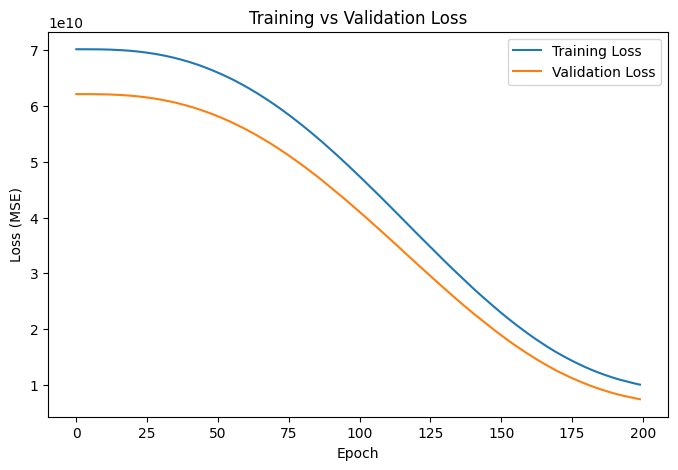

In [49]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## 12. Early Stopping (callback)

- Prevent overfitting
- will not waste the computing power
- save time
  
It is hard to guess exactly how many epochs a model needs. If you train for too few epochs, the model underfits. If you train for too many, it overfits. 

An **Early Stopping Callback** acts as an automatic brake. It monitors the validation loss and automatically stops training once the validation score stops improving, even if you haven't reached your maximum number of epochs. It can also automatically restore the model's best weights!

In [51]:
# configure EarlyStopping parameters
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [52]:
# Use the validation
# Step 1: Define
model9 = Sequential()
model9.add(Dense(30, activation='relu'))
model9.add(Dense(20, activation='relu'))
model9.add(Dense(15, activation='relu'))
model9.add(Dense(1, activation='linear'))
# Step 2: Compile 

model9.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Step 3: Fit

history = model9.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=16,
    callbacks=[es],
    verbose=1
)

Epoch 1/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 68027396096.0000 - mae: 232766.6094 - val_loss: 62151376896.0000 - val_mae: 221362.0312
Epoch 2/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - loss: 71287078912.0000 - mae: 237026.4375 - val_loss: 62150959104.0000 - val_mae: 221361.0781
Epoch 3/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 64515457024.0000 - mae: 226283.9375 - val_loss: 62149902336.0000 - val_mae: 221358.7344
Epoch 4/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - loss: 68916551680.0000 - mae: 232689.5781 - val_loss: 62147305472.0000 - val_mae: 221352.8438
Epoch 5/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 70258868224.0000 - mae: 233540.5625 - val_loss: 62141374464.0000 - val_mae: 221339.3906
Epoch 6/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - loss: 73716170752.0000 - mae: 240351.6875 - val_loss: 62129143808.0000 - val_mae: 221311.7656
Epoch 7/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - loss: 64131739648.0000 - mae: 227629.8906 - val_loss:

In [53]:
# Model Weights
model9.weights

[<Variable path=sequential_10/dense_31/kernel, shape=(1, 30), dtype=float32, value=[[ 2.5834794e+00  2.3949285e+00  2.5581157e+00  2.5928001e+00
   -6.1138296e-01 -2.2434304e-02  2.8171792e+00 -2.7302573e-03
    2.6359816e+00 -4.8556334e-01 -4.8732045e-01 -5.0335252e-01
    2.8091723e-01  2.3503723e+00  2.8174372e+00 -4.8725501e-01
    2.6751387e+00  9.0280277e-01 -8.0319112e-03 -5.1147807e-01
   -6.1214495e-01 -1.9049394e-01 -5.1033741e-01  2.2502439e-03
   -1.3550234e-01  2.6648448e+00  1.7992784e+00  2.7399445e+00
   -4.0574026e-01  2.6135266e+00]]>,
 <Variable path=sequential_10/dense_31/bias, shape=(30,), dtype=float32, value=[ 3.1762974   3.1401546   3.086273    3.167063    3.0356297  -0.04047967
   3.2486796  -0.00776     3.1867073   2.909113    3.0655355   3.1622813
   3.1803944   3.0528538   3.253916    3.0613458   3.1914413   3.1411827
  -0.01694393  3.2024376   3.1469367   3.1715856   3.1975706  -0.03155922
   3.1656854   3.0855427   3.0938377   3.2212162   3.1792111   3.026

In [54]:
# Model Summary
model9.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,035 (11.86 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,024 (7.91 KB)

In [55]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,7.019758e+10,234511.250000,6.215138e+10,221362.031250
1,7.019731e+10,234510.687500,6.215096e+10,221361.078125
2,7.019657e+10,234509.250000,6.214990e+10,221358.734375
3,7.019479e+10,234505.546875,6.214731e+10,221352.843750
4,7.019062e+10,234496.609375,6.214137e+10,221339.390625
...,...,...,...,...
118,8.399349e+09,63352.410156,6.085120e+09,57598.062500
119,8.402539e+09,63409.605469,6.086525e+09,57638.964844
120,8.402518e+09,63371.832031,6.085263e+09,57609.628906
121,8.397763e+09,63418.007812,6.086430e+09,57651.960938


Text(0, 0.5, 'loss')

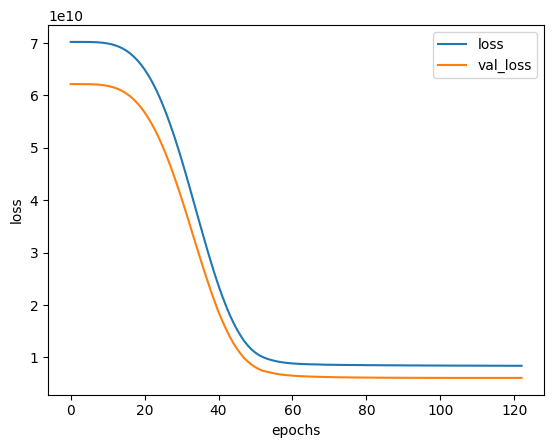

In [56]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss')

## 13.Multi-Feature Neural Network

In [58]:
X = housing[['beds', 'baths', 'sq__ft']]
y = housing['price']

In [59]:
X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all, test_size=0.20, random_state=42)

ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_val_scaled = ss.transform(X_val)
X_test_scaled = ss.transform(X_test)

In [60]:
# configure EarlyStopping parameters
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [61]:
# Use the validation
# Step 1: Define
model10 = Sequential()
model10.add(Dense(30, activation='relu'))
model10.add(Dense(20, activation='relu'))
model10.add(Dense(15, activation='relu'))
model10.add(Dense(1, activation='linear'))


# Step 2: Compile 

model10.compile(optimizer='adam', loss='mse', metrics=['mae'])


# Step 3: Fit
history = model10.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=16,
    callbacks=[es],
    verbose=1
)


Epoch 1/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 69433589760.0000 - mae: 232383.4375 - val_loss: 62151028736.0000 - val_mae: 221360.9844
Epoch 2/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 70356197376.0000 - mae: 234745.6406 - val_loss: 62149754880.0000 - val_mae: 221358.0156
Epoch 3/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss: 70018195456.0000 - mae: 232370.0625 - val_loss: 62146326528.0000 - val_mae: 221349.9844
Epoch 4/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 71388037120.0000 - mae: 235040.6406 - val_loss: 62137778176.0000 - val_mae: 221330.2969
Epoch 5/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 65959571456.0000 - mae: 231089.6719 - val_loss: 62118727680.0000 - val_mae: 221286.7812
Epoch 6/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - loss: 69671190528.0000 - mae: 234547.1250 - val_loss: 62080131072.0000 - val_mae: 221200.1406
Epoch 7/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 66650521600.0000 - mae: 230232.8750 - val_loss:

In [62]:
# Model Weights
model10.weights

[<Variable path=sequential_11/dense_35/kernel, shape=(3, 30), dtype=float32, value=[[-0.4456494   0.06251367  0.31206062  0.6430156   0.08477644 -0.21456766
    0.6635149  -0.2369939  -0.46848506  0.40858576  0.18005648 -0.7946602
   -0.5294655   0.17527992  0.3126835  -0.36249298 -0.42889932 -0.06056468
    0.13613166 -0.0306683  -0.6384471  -0.7612778  -0.81454134 -0.6109256
   -0.01503556 -0.48357376 -0.5896942  -0.24667524  0.21675803  0.20772716]
  [-1.325058    1.0392784   0.692545    0.5882731   0.89491117  0.9004811
    0.1168595   1.1591393  -1.1520762   0.77452123  1.1793814  -1.0739006
   -0.10863349  1.2934746   0.51861465 -0.7396262  -1.155278    1.1802583
    1.3085291   0.97193366 -1.124645   -0.50962937 -0.98360735 -1.1274635
    1.2330569  -0.5066696  -0.25590095 -1.7106695   0.933601    0.8660377 ]
  [ 0.84001064  1.7134204   1.9724791   1.4626656   1.9520326   1.9285519
    1.8527486   2.0704546   0.52938145  1.7016033   1.3822176   0.6720544
    0.12491328  1.903047

In [63]:
# Model Summary
model10.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 30)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,215 (12.56 KB)

 Trainable params: 1,071 (4.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,144 (8.38 KB)

In [64]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mae,val_loss,val_mae
0,7.019743e+10,234510.765625,6.215103e+10,221360.984375
1,7.019667e+10,234509.140625,6.214975e+10,221358.015625
2,7.019446e+10,234504.531250,6.214633e+10,221349.984375
3,7.018883e+10,234492.640625,6.213778e+10,221330.296875
4,7.017517e+10,234464.671875,6.211873e+10,221286.781250


Text(0, 0.5, 'loss')

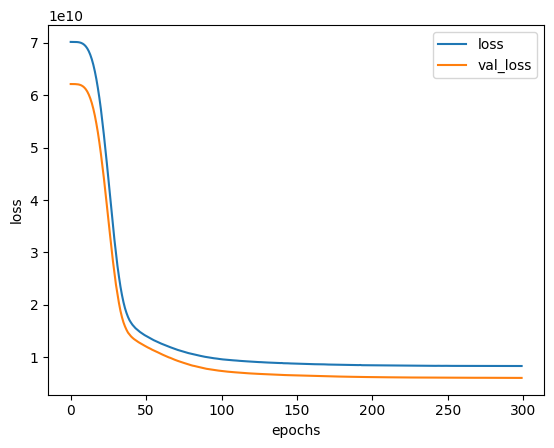

In [66]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss')